In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from params import Params, save_params_json
from datasets import (
    Era5Metadata,
    load_era5_data,
    prepare_meteoswiss_targets,
    calculate_dists_meteoswiss,
    save_metadata_json,
)
from convCNP.models.elev_models import TmaxBiasConvCNPElev, GammaBiasConvCNPElev
from convCNP.models.cnn import CNN, ResConvBlock
from convCNP.training.training_elev import train_elev
from convCNP.training.loss_functions import gll, gamma_ll
from convCNP.training.utils import get_value_tmax

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else
                      'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Training configuration - modify these parameters as needed
PARAMS = Params(
    VARIABLE='tmax',
    DATA_YEAR_START=2023,  # Set to None for full dataset
    N_EPOCHS=30,
    N_FOLDS=5,
    RUN_NAME='base-30-5folds',
)

print(f"Configuration: {PARAMS}")

In [4]:
OUTPUT_DIR = os.path.join('trained_models', PARAMS.RUN_NAME)

ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
ERA5_PRECIP_GLOB = './datasets/ERA5_Land/precipitation/*.nc'

EOBS_MAX_TEMP_GLOB = './datasets/EOBS/max_temperature/*.nc'
EOBS_PRECIP_GLOB = './datasets/EOBS/precipitation/*.nc'

METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
METEO_SWISS_PRECIP_GLOB = './datasets/MeteoSwiss/RhiresD_v2.0_swiss.lv95/*.nc'

# Auto-set data paths based on variable
# TODO: rewire this to be used below
if PARAMS.VARIABLE == 'tmax':
    GRID_INPUTS, GRID_TARGETS = ERA5_MAX_TEMP_GLOB, METEO_SWISS_MAX_TEMP_GLOB
elif PARAMS.VARIABLE == 'precip':
    GRID_INPUTS, GRID_TARGETS = ERA5_PRECIP_GLOB, METEO_SWISS_PRECIP_GLOB
ELEV_INPUTS = ''  # Empty for now

In [ ]:
# Load ERA5 input data using imported function
train_input_ds, era5_metadata = load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=PARAMS.DATA_YEAR_START,
    device=device
)

Loading ERA5 data from: ./datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32


In [ ]:
# Load MeteoSwiss targets using imported function
target_x, target_y, target_topo = prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=era5_metadata,
    data_var='TmaxD',
    elev_var=None,
    convert_to_kelvin=True,
    year_start=PARAMS.DATA_YEAR_START
)

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Warning: No elevation variable found. Filling ALL 3 features with Zeros.
Final X (Locations): Frozen({'point': 88800, 'coord': 2})
Final Y (Targets):   Frozen({'time': 365, 'point': 88800})
Final E (Topo):      Frozen({'point': 88800, 'fea

In [ ]:
# Calculate distances using imported function
dists = calculate_dists_meteoswiss(era5_metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

In [ ]:
def build_model(variable, n_channels, n_blocks, kernel_size, length_scale, in_channels):
    """
    Build convCNP model based on variable type

    Returns:
        model: nn.Module
        loss_fn: function
        get_value_fn: function to extract predictions from model output
    """
    # Build CNN decoder (same architecture for both variables)
    decoder = CNN(
        n_channels=n_channels,
        ConvBlock=ResConvBlock,
        n_blocks=n_blocks,
        Conv=nn.Conv2d,
        Normalization=nn.Identity,
        kernel_size=kernel_size
    )

    # Build model based on variable
    if variable == 'tmax':
        print("Building TmaxBiasConvCNPElev model...")
        model = TmaxBiasConvCNPElev(
            decoder=decoder,
            in_channels=in_channels,
            ls=length_scale
        )
        loss_fn = gll
        get_value_fn = get_value_tmax

    elif variable == 'precip':
        print("Building GammaBiasConvCNPElev model...")
        model = GammaBiasConvCNPElev(
            decoder=decoder,
            in_channels=in_channels,
            ls=length_scale
        )
        loss_fn = gamma_ll
        # For precipitation, we need a custom function
        def get_value_precip(p):
            """Extract mean prediction for precipitation"""
            # For Gamma distribution, mean = alpha / beta
            # Only predict non-zero when rho > 0.5
            mean = p[:, :, 1] / p[:, :, 2]  # alpha / beta
            mean[p[:, :, 0] <= 0.5] = 0  # Set to 0 when dry
            return mean
        get_value_fn = get_value_precip

    else:
        raise ValueError(f"Unknown variable: {variable}")

    # Count parameters
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model has {n_params:,} trainable parameters")

    return model, loss_fn, get_value_fn

In [11]:
def set_seed(seed):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(PARAMS.SEED)

In [ ]:
# Create output directory if it doesn't exist
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

save_params_json(PARAMS, output_dir / 'params.json')
save_metadata_json(era5_metadata, output_dir / 'metadata.json')

# Create a flat elevation map
# Fix: target_y has dimension 'point' (from stacking N, E), not 'latitude'/'longitude'
num_target_points = target_y.sizes['point']
print(f"Number of target points: {num_target_points}")
elev = torch.zeros(num_target_points, 3).to(device)

train_target_ds = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"train_target_ds shape: {train_target_ds.shape}, dtype: {train_target_ds.dtype}  # Expected: (time, n_points), float32")

# Loop over cross-validation folds
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')
# clear file contents
with open(stats_file, 'w') as f:
    f.write('Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n')  # Write header

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    # Reset model weights and optimizer for each fold
    set_seed(PARAMS.SEED + fold)  # Use a different seed for each fold for robustness
    model, loss_fn, get_value_fn = build_model(PARAMS.VARIABLE, PARAMS.N_CHANNELS, PARAMS.N_BLOCKS, PARAMS.KERNEL_SIZE, PARAMS.LENGTH_SCALE, PARAMS.IN_CHANNELS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    # Note: fold splitting logic is inside train_elev
    # Train the model
    train_elev(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        elev=elev,
        dists=dists,
        y_context=train_input_ds,
        y_target=train_target_ds,
        output_dir=OUTPUT_DIR,
        y_target_t=None,  # did not figure out what this does, it's not used internally in Vaughan et al's code
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        stats_file=stats_file
    )

print(f'\nTraining finished for all {PARAMS.N_FOLDS} folds. Models saved in {output_dir}.')

Number of target points: 88800
train_target_ds shape: torch.Size([365, 88800]), dtype: torch.float32  # Expected: (time, n_points), float32

Starting fold 1/5...

Building TmaxBiasConvCNPElev model...
Model has 281,805 trainable parameters
Training
Starting epoch: 0


/home/rage/.pyenv/versions/3.13.1/envs/capstone/lib/python3.13/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/rage/.pyenv/versions/3.13.1/envs/capstone/lib/python3.13/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Mean absolute error: 1.01060289144516
Pearson correlation: 0.9098654389381409
Spearman correlation: 0.9033285809507967
Epoch 0: train NLL 1.654, test NLL 2.513
Starting epoch: 1
Mean absolute error: 1.080843210220337
Pearson correlation: -0.9035138189792633
Spearman correlation: -0.8957484882142418
Epoch 1: train NLL 1.415, test NLL 1.693
Starting epoch: 2
Mean absolute error: 0.9951550364494324
Pearson correlation: 0.8681108057498932
Spearman correlation: 0.8624892015302974
Epoch 2: train NLL 1.367, test NLL 1.694
Starting epoch: 3
Mean absolute error: 1.0112969279289246
Pearson correlation: 0.8748034238815308
Spearman correlation: 0.868382080710848
Epoch 3: train NLL 1.418, test NLL 1.582
Starting epoch: 4
Mean absolute error: 0.9870801270008087
Pearson correlation: 0.8582774698734283
Spearman correlation: 0.8585400468962114
Epoch 4: train NLL 1.265, test NLL 1.511
Starting epoch: 5
Mean absolute error: 0.8824435472488403
Pearson correlation: 0.9106483161449432
Spearman correlation: 

In [ ]:
stats = pd.read_csv(stats_file)
stats

,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,1,1.010603,0.909865,0.903329,0,1.654,2.513
1,1,1.080843,-0.903514,-0.895748,1,1.415,1.693
2,1,0.995155,0.868111,0.862489,2,1.367,1.694
3,1,1.011297,0.874803,0.868382,3,1.418,1.582
4,1,0.987080,0.858277,0.858540,4,1.265,1.511
...,...,...,...,...,...,...,...
145,5,0.223930,0.878738,0.874830,25,0.371,0.365
146,5,0.242016,0.877382,0.872054,26,0.357,0.357
147,5,0.213112,0.881136,0.876466,27,0.309,0.306
148,5,0.208951,0.879385,0.874954,28,0.275,0.286


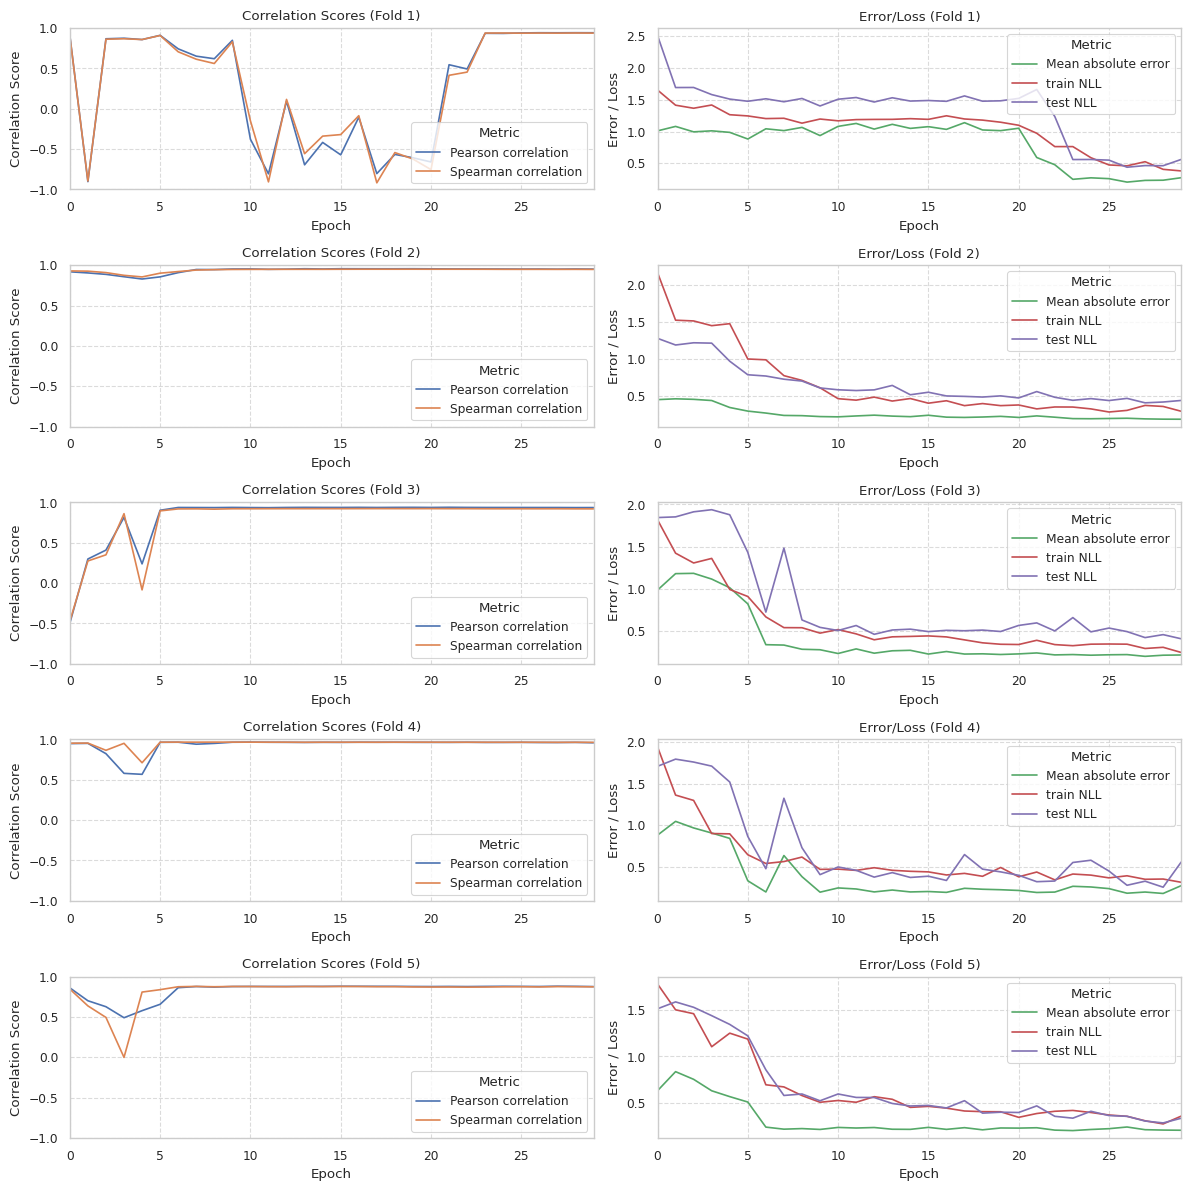

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper", style="whitegrid")

folds = sorted(stats['Fold'].unique())
n_folds = len(folds)

fig, axes = plt.subplots(nrows=n_folds, ncols=2, figsize=(12, 12), sharex=False)

for i, fold in enumerate(folds):
    fold_stats = stats[stats['Fold'] == fold]

    palette = sns.color_palette()

    # Plot correlations
    ax = axes[i, 0]

    # Convert to long format
    fold_stats_long = fold_stats.melt(
        id_vars='Epoch',
        value_vars=['Pearson correlation', 'Spearman correlation'],
        var_name='Metric',
        value_name='Correlation'
    )

    sns.lineplot(
        data=fold_stats_long,
        x='Epoch',
        y='Correlation',
        hue='Metric',
        palette={'Pearson correlation': palette[0], 'Spearman correlation': palette[1]},
        ax=ax
    )

    ax.set_title(f'Correlation Scores (Fold {fold})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Correlation Score')
    ax.set_ylim(-1, 1)
    ax.set_xlim(0, stats['Epoch'].max())
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Metric', loc='lower right')

    # Plot errors
    ax = axes[i, 1]

    # Convert to long format
    fold_stats_long = fold_stats.melt(
        id_vars='Epoch',
        value_vars=['Mean absolute error', 'train NLL', 'test NLL'],
        var_name='Error / Loss',
        value_name='Value'
    )

    sns.lineplot(
        data=fold_stats_long,
        x='Epoch',
        y='Value',
        hue='Error / Loss',
        palette={'Mean absolute error': palette[2], 'train NLL': palette[3], 'test NLL': palette[4]},
        ax=ax
    )

    ax.set_title(f'Error/Loss (Fold {fold})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Error / Loss')
    # ax.set_ylim(0.98, 0.99)
    ax.set_xlim(0, stats['Epoch'].max())
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Metric', loc='upper right')

plt.tight_layout()
plt.show()
